# Six-class Pointwise MLP · 10 presynaptic embeddings + post · 5 folds

Classes: BasketFam, BipFam, MartFam, NglFam, pyramidal, thalamocortical. CAVE skeleton n10 pre + post models, folds 0–4, using saved best-checkpoint metrics and training curves. No new inference or training is performed.

Fold means weight completed folds equally; standard deviations use ddof=1. Validation and testing share the original held-out split, so these are not independent final test estimates. Run All to refresh the saved snapshot.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'scripts/train_gnn.py').is_file())
RESULT_ROOT = ROOT / 'results/presynaptic/cave_skeletons_pre_post/k10/conf0.7/six_class'
RUN = 'gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_n10_mixed16_sampled_pre_post'
MODEL = 'Pointwise MLP · 10 presynaptic embeddings + post · 5 folds'
FOLDS = range(5)
COLORS = plt.get_cmap('tab10').colors[:5]
pd.options.display.float_format = '{:.4f}'.format


## Fold status and best-checkpoint performance

Each fold shows its latest recorded epoch and whether final results are available. Running folds use best_metrics.json; completed folds use the final result JSON. Aggregates include completed folds only.

In [2]:
def read_metrics(path):
    try:
        return json.loads(path.read_text())
    except (FileNotFoundError, json.JSONDecodeError):
        return None  # A training job may currently be writing this file.

status, rows, payloads, curves = [], [], {}, {}
metric_columns = [f'{scope}_{metric}' for scope in ('window', 'cell')
                  for metric in ('accuracy', 'balanced_accuracy', 'macro_precision', 'macro_f1')]
for fold in FOLDS:
    directory = RESULT_ROOT / f'fold{fold}' / 'pre_post'
    path = directory / f'{RUN}_fold{fold}.json'
    run_directory = directory / f'{RUN}_fold{fold}'
    curve_path = run_directory / 'epoch_metrics.csv'
    if curve_path.exists():
        try:
            frame = pd.read_csv(curve_path).dropna(subset=['epoch']).sort_values('epoch')
            if not frame.empty:
                curves[fold] = frame
        except (pd.errors.EmptyDataError, pd.errors.ParserError):
            pass
    payload = read_metrics(path)
    complete = payload is not None
    if payload is None:
        payload = read_metrics(run_directory / 'best_metrics.json')
    state = 'complete' if complete else ('in progress (best so far)' if payload else
            'in progress (epoch metrics)' if fold in curves else 'awaiting metrics')
    status.append(dict(fold=fold, status=state,
                       latest_epoch=int(curves[fold].epoch.max()) if fold in curves else None,
                       epochs_recorded=len(curves[fold]) if fold in curves else 0,
                       result=str((path if complete else run_directory).relative_to(ROOT))))
    if payload is None:
        continue
    if complete:
        assert payload['fold_index'] == fold, f'Fold mismatch: {path}'
    payload['best_epoch'] = payload.get('best_epoch', payload.get('epoch'))
    payloads[fold] = payload
    row = dict(fold=fold, complete=complete, best_epoch=payload['best_epoch'])
    for scope, key in [('window', 'window_test_metrics'), ('cell', 'test_metrics')]:
        for metric in ('accuracy', 'balanced_accuracy', 'macro_precision', 'macro_f1'):
            row[f'{scope}_{metric}'] = payload[key][metric]
        row[f'{scope}_support'] = np.asarray(payload[key]['confusion_matrix']).sum()
    rows.append(row)
print('Snapshot refreshed:', pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'))
display(pd.DataFrame(status))
summary = pd.DataFrame(rows, columns=['fold', 'complete', 'best_epoch', *metric_columns,
                                     'window_support', 'cell_support']).set_index('fold').sort_index()
if not summary.empty:
    print('Saved best-checkpoint metrics; complete=False means provisional.')
    display(summary)
completed = summary[summary.complete.eq(True)]
print(f'Completed folds: {len(completed)}/5. Rerun all cells to refresh this snapshot.')
if not completed.empty:
    aggregate = completed[metric_columns].agg(['count', 'mean', 'std', 'min', 'max']).T
    aggregate.index.name = 'metric'
    print('Aggregate uses completed folds only (sample standard deviation, ddof=1).')
    display(aggregate)
else:
    print('Awaiting completed folds; training curves and available best-so-far metrics are shown below.')


Snapshot refreshed: 2026-10-09 14:17:26


,fold,status,latest_epoch,epochs_recorded,result
0,0,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
1,1,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
2,2,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
3,3,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...
4,4,complete,29,30,results/presynaptic/cave_skeletons_pre_post/k1...


Saved best-checkpoint metrics; complete=False means provisional.


,complete,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,window_support,cell_support
fold,,,,,,,,,,,,
0,True,29,0.8502,0.6997,0.7118,0.6998,0.9694,0.8761,0.9702,0.9087,293953,359
1,True,29,0.8760,0.7151,0.7317,0.7198,0.9524,0.8102,0.9475,0.8411,303352,357
2,True,26,0.8748,0.7536,0.7319,0.7398,0.9520,0.8733,0.9433,0.8831,288259,354
3,True,20,0.8358,0.6947,0.7372,0.7085,0.9348,0.8009,0.9456,0.8489,297192,353
4,True,21,0.8796,0.7193,0.7643,0.7328,0.9429,0.7604,0.9474,0.7878,290232,350


Completed folds: 5/5. Rerun all cells to refresh this snapshot.
Aggregate uses completed folds only (sample standard deviation, ddof=1).


,count,mean,std,min,max
metric,,,,,
window_accuracy,5.0000,0.8633,0.0193,0.8358,0.8796
window_balanced_accuracy,5.0000,0.7165,0.0232,0.6947,0.7536
window_macro_precision,5.0000,0.7354,0.0188,0.7118,0.7643
window_macro_f1,5.0000,0.7201,0.0165,0.6998,0.7398
cell_accuracy,5.0000,0.9503,0.0129,0.9348,0.9694
cell_balanced_accuracy,5.0000,0.8242,0.0498,0.7604,0.8761
cell_macro_precision,5.0000,0.9508,0.0110,0.9433,0.9702
cell_macro_f1,5.0000,0.8539,0.0459,0.7878,0.9087


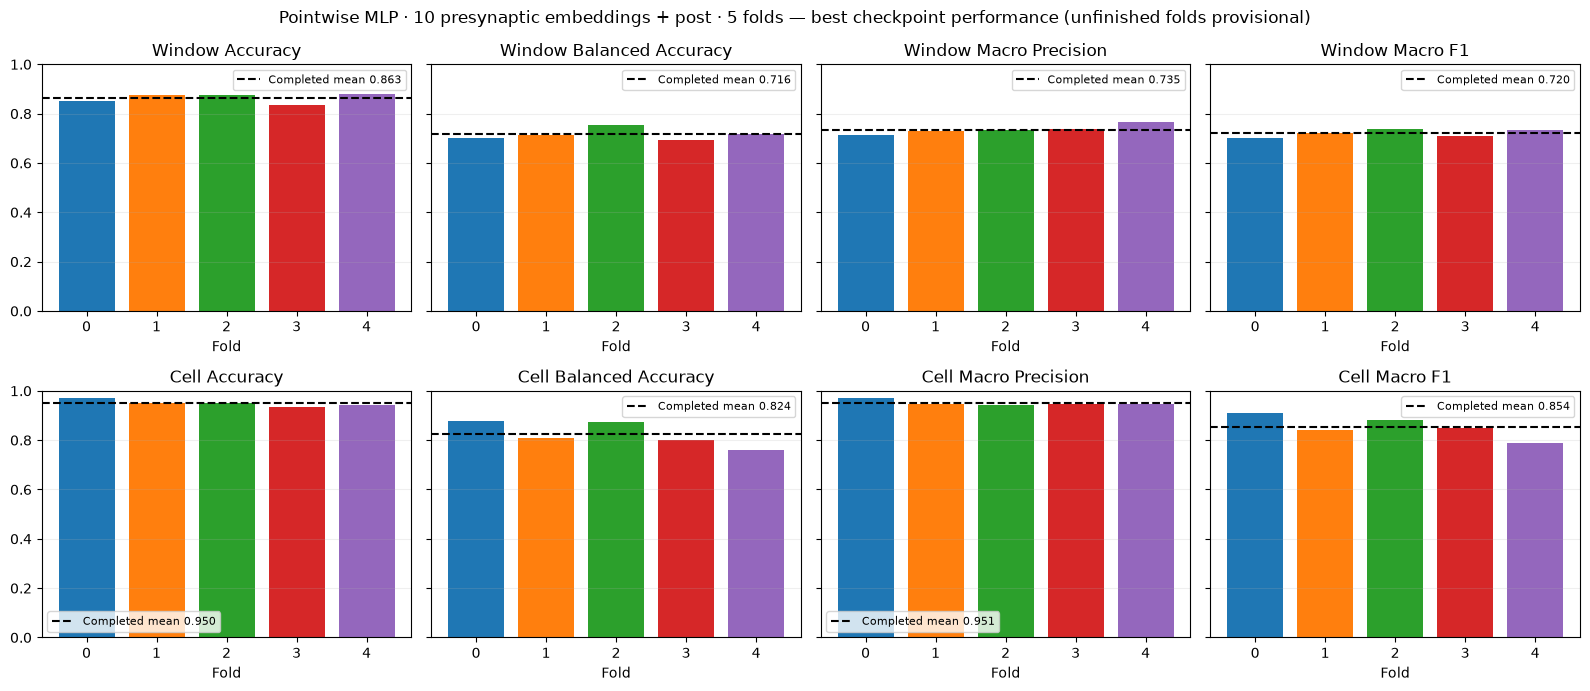

In [3]:
if payloads:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
    for ax, metric in zip(axes.flat, metric_columns):
        values = summary[metric]
        ax.bar(values.index, values, color=[COLORS[f] for f in values.index])
        if not completed.empty:
            mean = completed[metric].mean()
            ax.axhline(mean, color='black', linestyle='--', label=f'Completed mean {mean:.3f}')
        ax.set(title=metric.replace('_', ' ').title(), xlabel='Fold', xticks=list(FOLDS), ylim=(0, 1))
        ax.grid(axis='y', alpha=.2)
        ax.legend(fontsize=8)
    fig.suptitle(MODEL + ' — best checkpoint performance (unfinished folds provisional)')
    fig.tight_layout()
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')

## Training trajectories

Separate lines show each fold. Dots mark the saved best epoch on held-out F1 curves; these epochs can differ across folds.

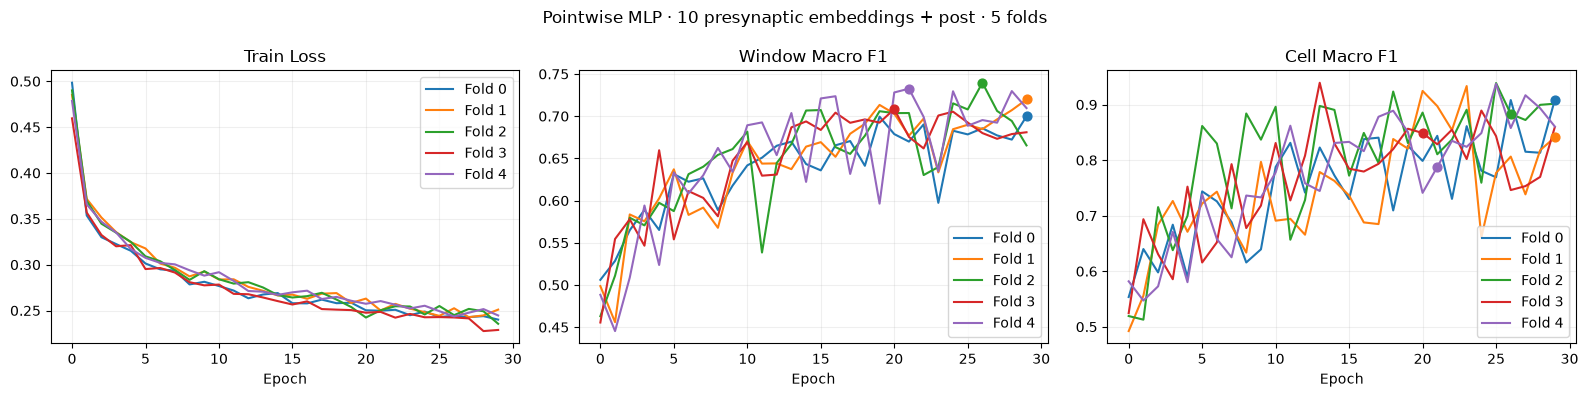

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['train_loss', 'window_macro_f1', 'cell_macro_f1']):
    for fold, frame in curves.items():
        ax.plot(frame.epoch, frame[metric], color=COLORS[fold], label=f'Fold {fold}')
        if fold in payloads and metric != 'train_loss':
            best = frame[frame.epoch == payloads[fold]['best_epoch']]
            ax.scatter(best.epoch, best[metric], color=COLORS[fold], s=40, zorder=3)
    ax.set(title=metric.replace('_', ' ').title(), xlabel='Epoch')
    ax.grid(alpha=.2)
    if ax.lines:
        ax.legend()
fig.suptitle(MODEL)
fig.tight_layout()
plt.show()


## Per-class recall and support

Running folds show provisional best-checkpoint results. Per-class mean/std below includes all displayed folds; support counts explain rare-class variability.

Window recall by fold


fold,0,1,2,3,4,mean,std
BasketFam,0.9741,0.9149,0.9233,0.9475,0.9448,0.9409,0.0231
BipFam,0.3926,0.3309,0.3310,0.2796,0.2717,0.3211,0.0487
MartFam,0.7961,0.8708,0.7975,0.6063,0.8574,0.7856,0.1059
NglFam,0.5120,0.4074,0.6782,0.4888,0.5413,0.5255,0.0988
pyramidal,0.8711,0.9004,0.9226,0.9435,0.9099,0.9095,0.0269
thalamocortical,0.6524,0.8660,0.8692,0.9025,0.7907,0.8162,0.1003


Window support by fold


,0,1,2,3,4
BasketFam,87067,90954,90820,92848,96772
BipFam,13526,9873,8097,18650,11054
MartFam,60153,63795,64187,54376,53687
NglFam,2957,1274,1765,2017,981
pyramidal,116235,120908,112700,111017,111602
thalamocortical,14015,16548,10690,18284,16136


Cell recall by fold


fold,0,1,2,3,4,mean,std
BasketFam,1.0000,0.9688,0.9697,1.0000,1.0000,0.9877,0.0169
BipFam,0.5500,0.4000,0.3684,0.4545,0.1579,0.3862,0.1450
MartFam,0.9565,1.0000,0.9091,0.6957,0.9048,0.8932,0.1171
NglFam,0.7500,0.5000,1.0000,0.6667,0.5000,0.6833,0.2075
pyramidal,1.0000,0.9926,0.9926,0.9888,1.0000,0.9948,0.0050
thalamocortical,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000


Cell support by fold


,0,1,2,3,4
BasketFam,33,32,33,32,33
BipFam,20,20,19,22,19
MartFam,23,24,22,23,21
NglFam,4,4,4,3,4
pyramidal,273,271,270,267,267
thalamocortical,6,6,6,6,6


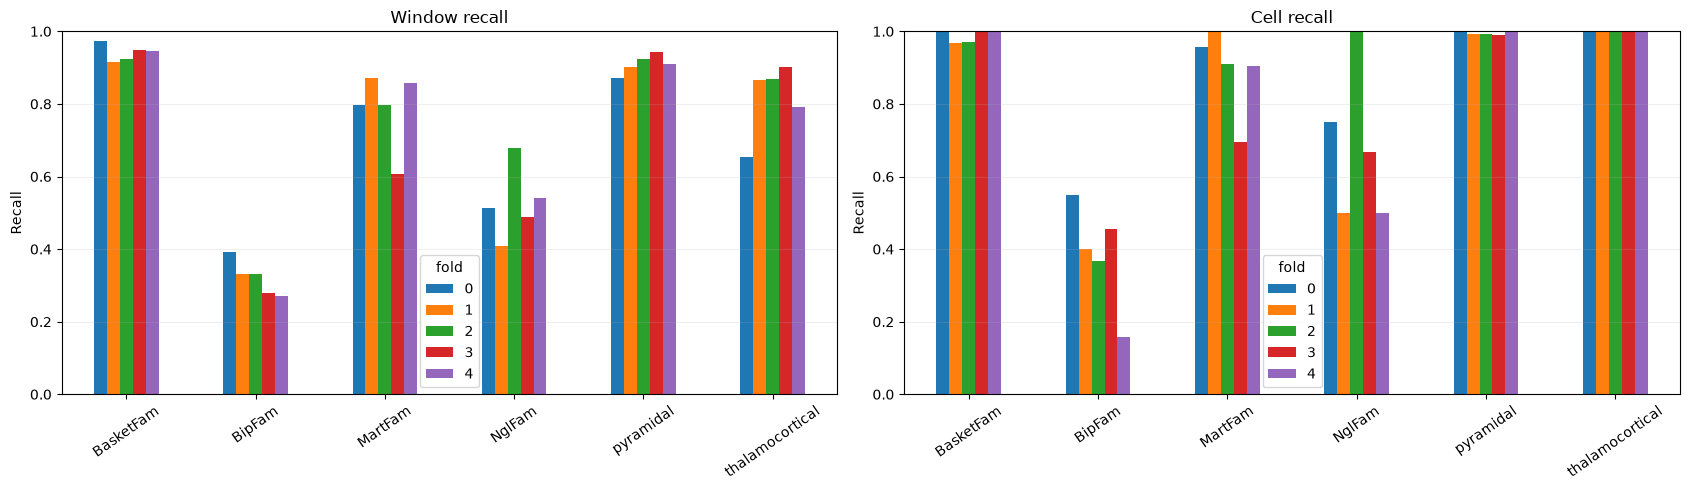

In [5]:
if payloads:
    classes = next(iter(payloads.values()))['classes']
    assert all(p['classes'] == classes for p in payloads.values()), 'Class ordering differs across folds'
    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    for ax, (scope, key) in zip(axes, [('window', 'window_test_metrics'), ('cell', 'test_metrics')]):
        recall = pd.DataFrame({fold: p[key]['per_class_recall'] for fold, p in payloads.items()}).reindex(classes)
        recall.columns.name = 'fold'
        support = pd.DataFrame({fold: np.asarray(p[key]['confusion_matrix']).sum(axis=1)
                                for fold, p in payloads.items()}, index=classes)
        print(f'{scope.title()} recall by fold')
        display(recall.assign(mean=recall.mean(axis=1), std=recall.std(axis=1, ddof=1)))
        print(f'{scope.title()} support by fold')
        display(support)
        recall.plot.bar(ax=ax, color=[COLORS[f] for f in recall.columns], rot=35)
        ax.set(title=f'{scope.title()} recall', ylabel='Recall', ylim=(0, 1))
        ax.grid(axis='y', alpha=.2)
    fig.tight_layout()
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')

## Confusion matrices across folds

Rows are true classes; columns are predicted classes. Each entry shows the row-normalized proportion and the raw count in parentheses. Running folds use provisional best-checkpoint results.

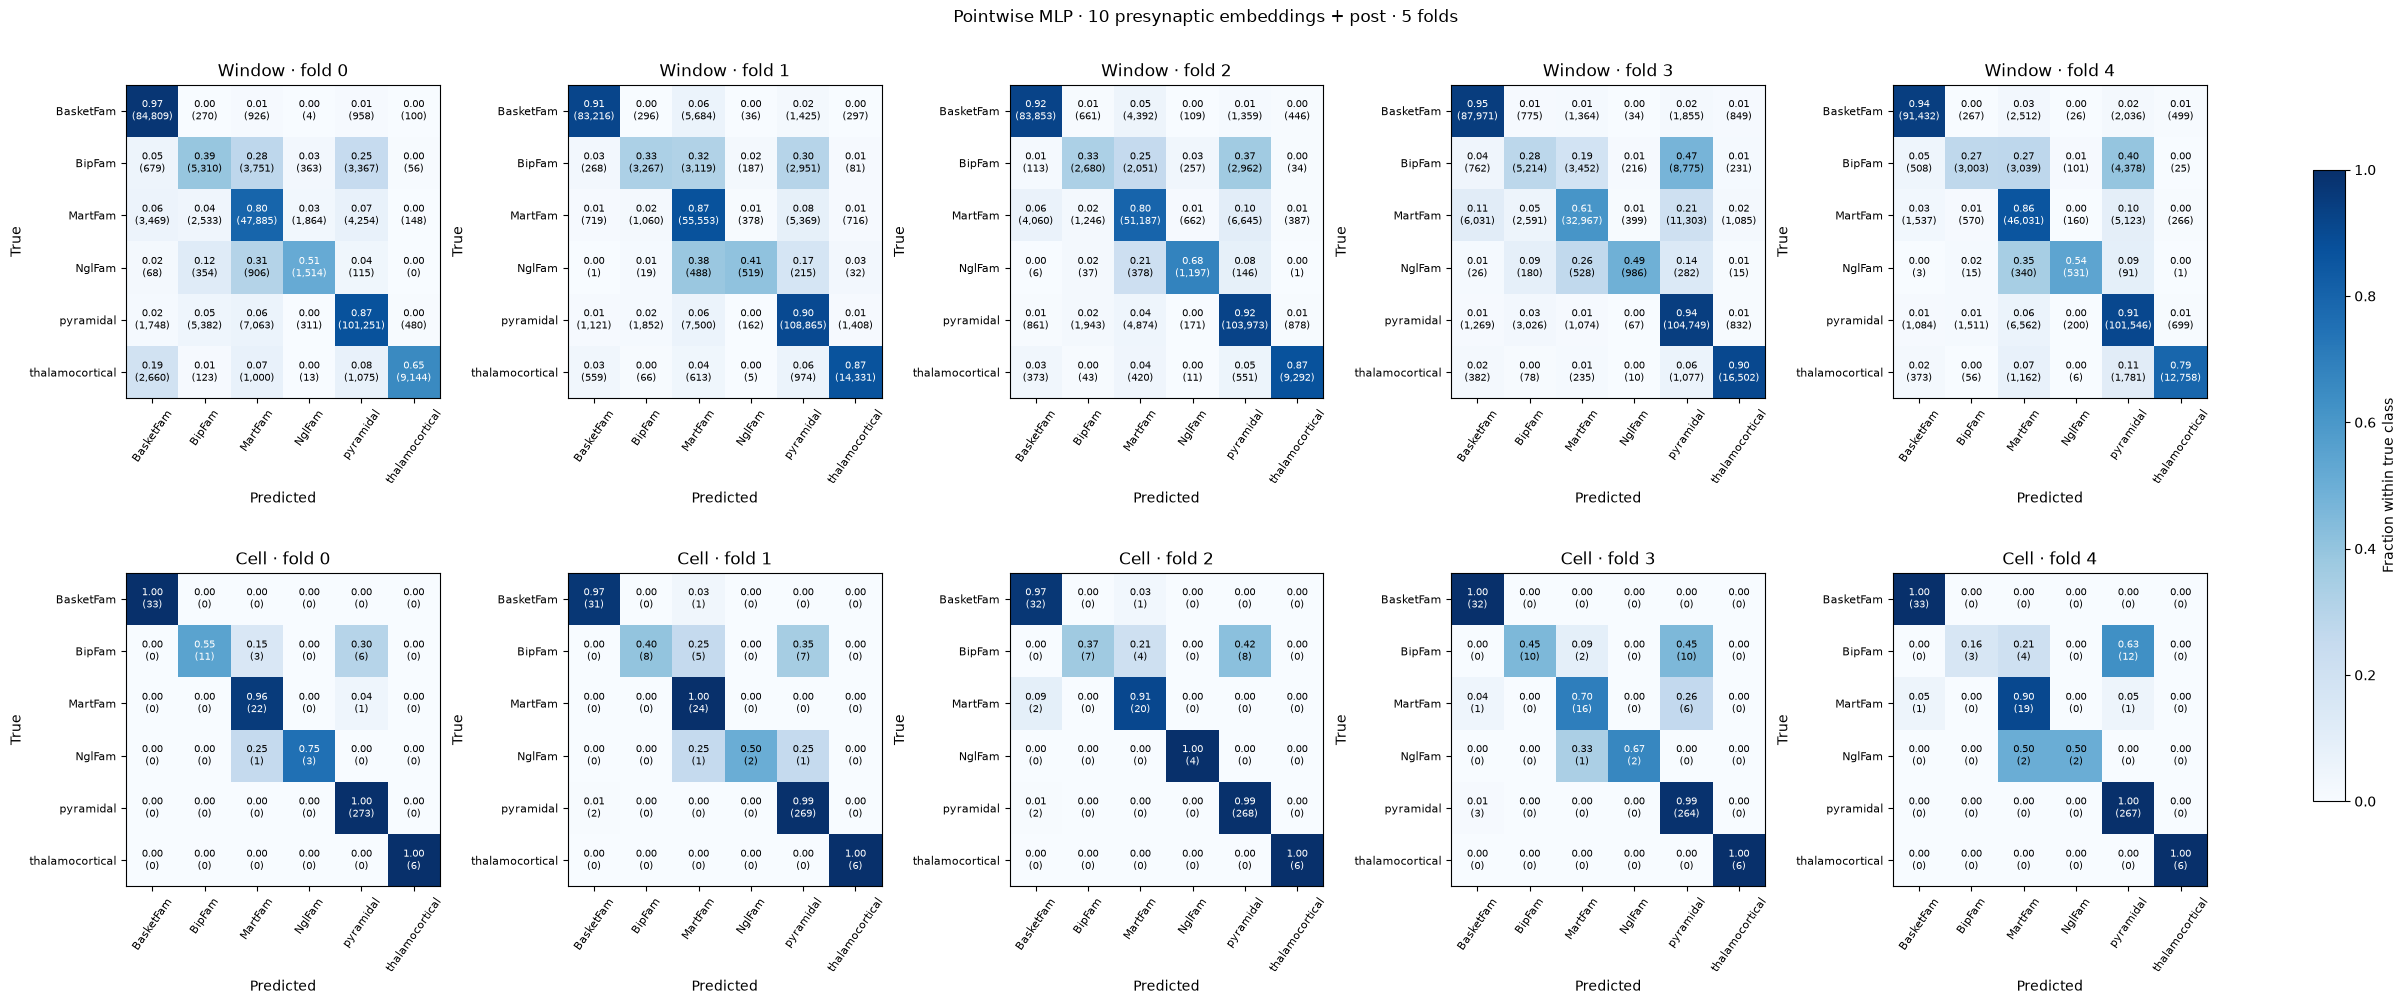

In [6]:
if payloads:
    fig, axes = plt.subplots(2, 5, figsize=(24, 10), layout='constrained')
    for row, (scope, key) in enumerate([('Window', 'window_test_metrics'), ('Cell', 'test_metrics')]):
        for fold in FOLDS:
            ax = axes[row, fold]
            if fold not in payloads:
                ax.set_title(f'{scope} · fold {fold}: unavailable')
                ax.axis('off')
                continue
            counts = np.asarray(payloads[fold][key]['confusion_matrix'])
            totals = counts.sum(axis=1, keepdims=True)
            normalized = np.divide(counts, totals, out=np.zeros_like(counts, dtype=float), where=totals != 0)
            im = ax.imshow(normalized, vmin=0, vmax=1, cmap='Blues')
            for (i, j), value in np.ndenumerate(normalized):
                ax.text(j, i, f'{value:.2f}\n({counts[i,j]:,})', ha='center', va='center', fontsize=7,
                        color='white' if value > .5 else 'black')
            ax.set(title=f'{scope} · fold {fold}', xticks=range(len(classes)), yticks=range(len(classes)),
                   xticklabels=classes, yticklabels=classes, xlabel='Predicted', ylabel='True')
            ax.tick_params(axis='x', rotation=55, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
    fig.colorbar(im, ax=axes, shrink=.7, label='Fraction within true class')
    fig.suptitle(MODEL)
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')